In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
from tqdm.auto import tqdm
from time_series import create_time_series
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import numpy as np

tqdm.pandas()

In [ ]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 423
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df.size

67530

In [6]:
df_filtered = df[(df["elapsed_days"] > 0)]

In [7]:
groups = df_filtered.groupby("rating")["duration"].median()

df_filtered["review_average"] = df_filtered["rating"].map(groups)

current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())

current_residual, groups

/tmp/ipykernel_114237/2144162587.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["review_average"] = df_filtered["rating"].map(groups)
/tmp/ipykernel_114237/2144162587.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["duration"] - x["review_average"]).mean())


(rating
 1    9001.423291
 2     426.000000
 3    6821.906898
 4       0.000000
 dtype: float64,
 rating
 1     7791.0
 2     4231.0
 3     4237.5
 4    10485.0
 Name: duration, dtype: float64)

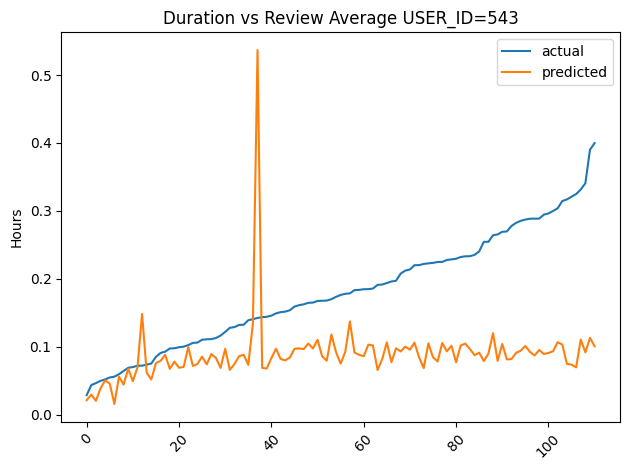

In [12]:
import matplotlib.pyplot as plt

# Group, sample, and prepare data
day_accuracies = df_filtered.groupby("day_offset")[["duration", "review_average"]].sum()
day_accuracies.sort_values("duration", inplace=True)
day_accuracies.reset_index(inplace=True)

# Optionally convert units now
day_accuracies["duration"] /= (1000 * 60 * 60)        # convert to hours
day_accuracies["review_average"] /= (1000 * 60 * 60)  # convert to hours

plt.plot(day_accuracies.index, day_accuracies["duration"], label="actual")
plt.plot(day_accuracies.index, day_accuracies["review_average"], label="predicted")

plt.ylabel("Hours")
plt.title(f"Duration vs Review Average {USER_ID=}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()
